Unemployment Analysis with Python

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [2]:
df = pd.read_csv("Unemployment in India.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


DATA CLEANING

 Remove extra spaces from column names

In [3]:
df.columns = df.columns.str.strip()

 Remove missing values

In [4]:
df.dropna(inplace=True)

 Convert Date column

In [5]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print("Dataset Shape:", df.shape)
print("\nMissing Values:\n")
print(df.isnull().sum())

Dataset Shape: (740, 7)

Missing Values:

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64


BASIC INFORMATION

In [6]:
print("\nDataset Info:\n")
print(df.info())

print("\nStatistical Summary:\n")
print(df.describe())


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB
None

Statistical Summary:

                                Date  Estimated Unemployment Rate (%)  \
count              

Visualization

UNEMPLOYMENT RATE DISTRIBUTION

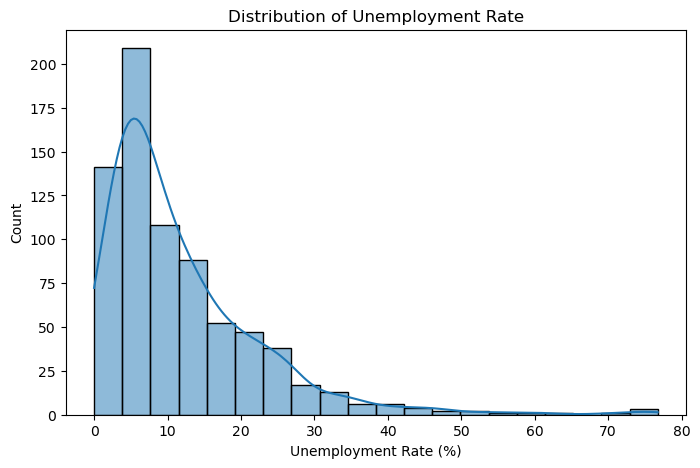

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Estimated Unemployment Rate (%)'],
    bins=20,
    kde=True
)

plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Count")
plt.show()

UNEMPLOYMENT RATE BY AREA

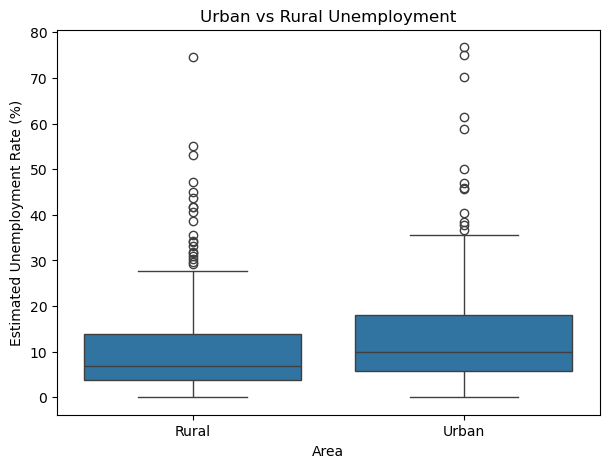

In [8]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Area',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title("Urban vs Rural Unemployment")
plt.show()


TOP 10 STATES WITH HIGHEST UNEMPLOYMENT

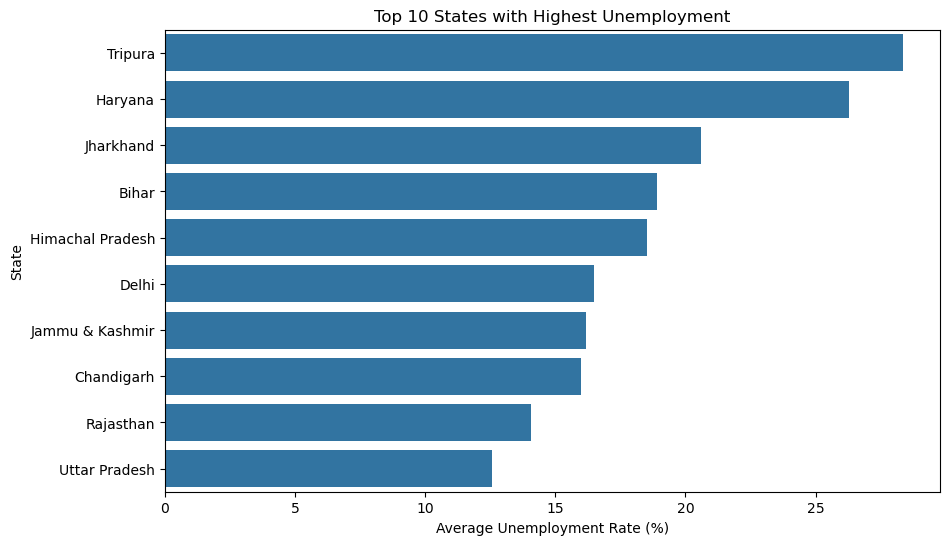

In [9]:
state_unemployment = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=state_unemployment.values,
    y=state_unemployment.index
)

plt.title("Top 10 States with Highest Unemployment")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")
plt.show()

MONTHLY UNEMPLOYMENT TREND

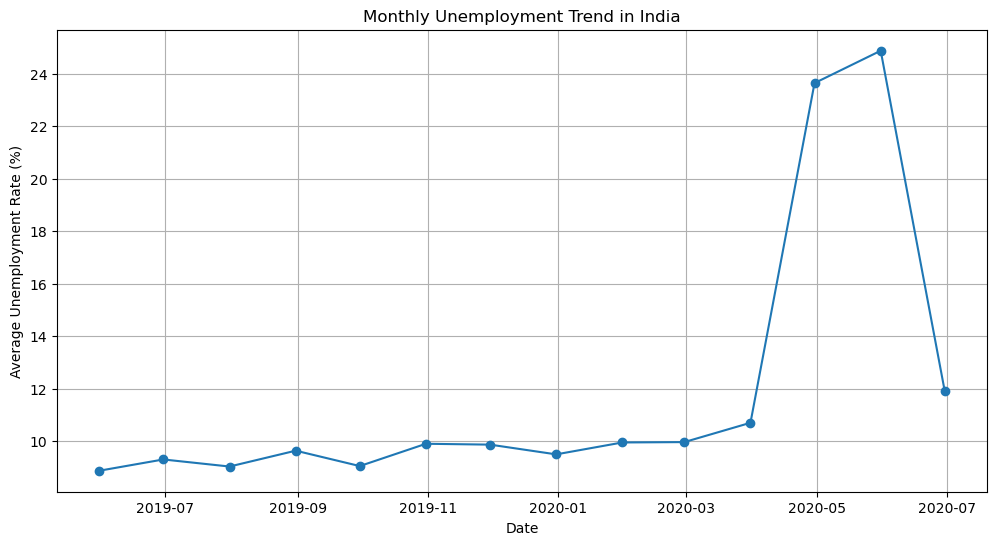

In [10]:
monthly_unemployment = (
    df.groupby('Date')['Estimated Unemployment Rate (%)']
      .mean()
      .reset_index()
)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_unemployment['Date'],
    monthly_unemployment['Estimated Unemployment Rate (%)'],
    marker='o'
)

plt.title("Monthly Unemployment Trend in India")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.grid(True)
plt.show()


COVID-19 IMPACT ANALYSIS

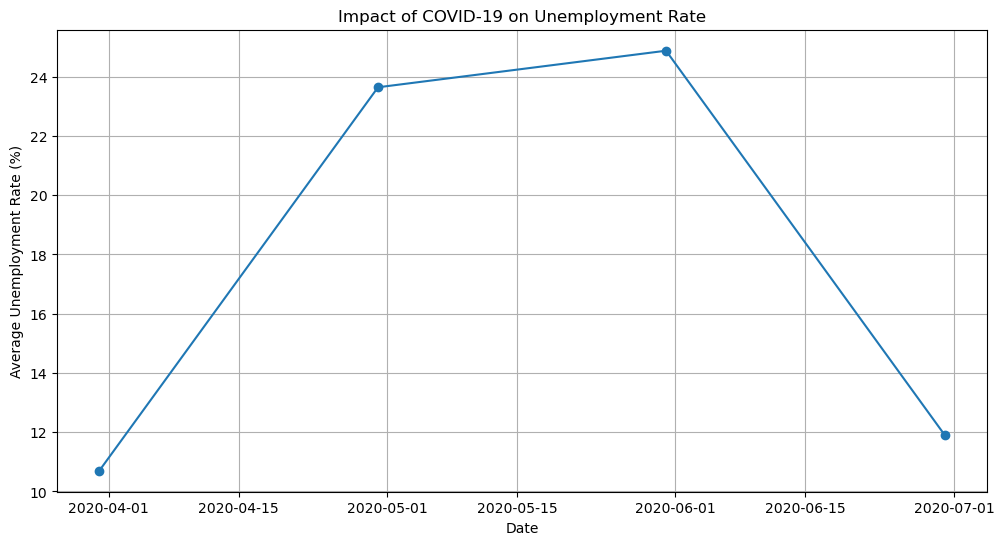

In [11]:
covid_period = df[df['Date'] >= '2020-03-01']

covid_monthly = (
    covid_period.groupby('Date')['Estimated Unemployment Rate (%)']
                .mean()
                .reset_index()
)

plt.figure(figsize=(12,6))

plt.plot(
    covid_monthly['Date'],
    covid_monthly['Estimated Unemployment Rate (%)'],
    marker='o'
)

plt.title("Impact of COVID-19 on Unemployment Rate")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.grid(True)
plt.show()


HEATMAP

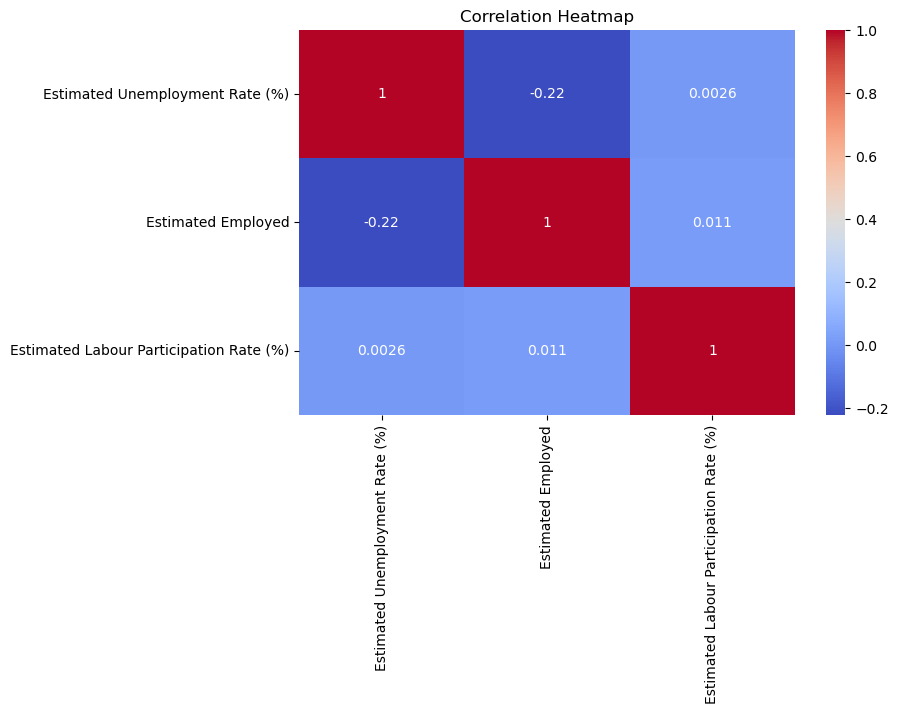

In [12]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[['Estimated Unemployment Rate (%)',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

Insights 

1. The unemployment rate is concentrated in the lower to moderate range, with only a few periods showing very high unemployment levels.

2. Urban and rural areas show noticeable differences in unemployment rates, indicating varying employment conditions across regions.

3. States such as Haryana, Tripura, and Jharkhand recorded higher average unemployment rates compared to many other states.

4. Unemployment rates fluctuated over time, with a sharp rise observed during the COVID-19 period followed by gradual stabilization.

5. The COVID-19 lockdown period caused a significant increase in unemployment, highlighting its impact on the labour market.

6. The correlation analysis shows that unemployment rate, employment levels, and labour participation rate are related and influence each other.